# Iterate over Test Images and calculate Top N (50) matches of the Examples

## Setup (Imports and Preparations)

In [1]:
import os

from albumentations import (
    Compose as ACompose,
    HorizontalFlip as AHorizontalFlip,
    VerticalFlip as AVerticalFlip
)

import matplotlib.pyplot as plt
from matplotlib import pyplot as plt

import os
import sys
import random 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
import ActivationExamples_SARSeg.examples_utils as utils
from ActivationExamples_SARSeg.examples_utils import *

c:\Users\k3ksy\anaconda3\envs\sar_seg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_lmdb_path = '../data/BigEarthNet/Encoded-BigEarthNet'
parquet_path = '../data/BigEarthNet/metadata.parquet'
examples_lmdb_path = "../data/BigEarthNet/examples_subsample_deeplabv3p"

device = 'cuda' if torch.cuda.is_available() else 'cpu'

seed=24
batch_size= 16
NUM_CLASSES = 20
n_classes = num_class = NUM_CLASSES

IMG_SIZE = (120,120)
IMG_HEIGHT = 120
IMG_WIDTH  = 120
IMG_CHANNELS = 2

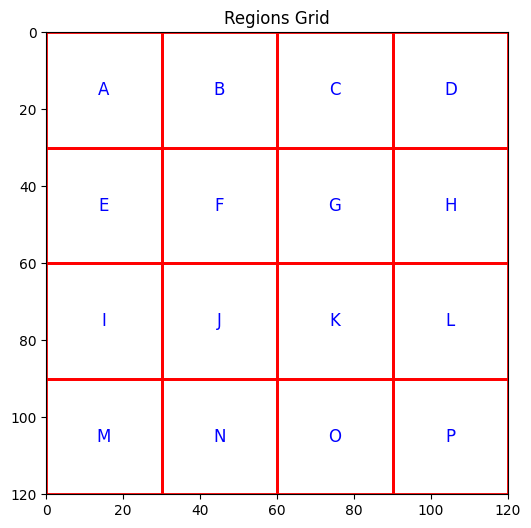

In [3]:
regions = {
    # First Row
    "A": (0, 0, IMG_WIDTH/4 , IMG_HEIGHT/4),
    "B": (IMG_WIDTH/4, 0, IMG_WIDTH/2, IMG_HEIGHT/4),
    "C": (IMG_WIDTH/2, 0, 3*IMG_WIDTH/4, IMG_HEIGHT/4),
    "D": (3*IMG_WIDTH/4, 0, IMG_WIDTH, IMG_HEIGHT/4),
    # Second Row
    "E": (0, IMG_HEIGHT/4, IMG_WIDTH/4, IMG_HEIGHT/2),
    "F": (IMG_WIDTH/4, IMG_HEIGHT/4, IMG_WIDTH/2, IMG_HEIGHT/2),
    "G": (IMG_WIDTH/2, IMG_HEIGHT/4, 3*IMG_WIDTH/4, IMG_HEIGHT/2),
    "H": (3*IMG_WIDTH/4, IMG_HEIGHT/4, IMG_WIDTH, IMG_HEIGHT/2),
    # Third Row
    "I": (0, IMG_HEIGHT/2, IMG_WIDTH/4, 3*IMG_HEIGHT/4),
    "J": (IMG_WIDTH/4, IMG_HEIGHT/2, IMG_WIDTH/2, 3*IMG_HEIGHT/4),
    "K": (IMG_WIDTH/2, IMG_HEIGHT/2, 3*IMG_WIDTH/4, 3*IMG_HEIGHT/4),
    "L": (3*IMG_WIDTH/4, IMG_HEIGHT/2, IMG_WIDTH, 3*IMG_HEIGHT/4),
    # Fourth Row
    "M": (0, 3*IMG_HEIGHT/4, IMG_WIDTH/4, IMG_HEIGHT),
    "N": (IMG_WIDTH/4, 3*IMG_HEIGHT/4, IMG_WIDTH/2, IMG_HEIGHT),
    "O": (IMG_WIDTH/2, 3*IMG_HEIGHT/4, 3*IMG_WIDTH/4, IMG_HEIGHT),
    "P": (3*IMG_WIDTH/4, 3*IMG_HEIGHT/4, IMG_WIDTH, IMG_HEIGHT),
}

fig, ax = plt.subplots(figsize=(6,6))

for label, (x1, y1, x2, y2) in regions.items():
    w = x2 - x1
    h = y2 - y1
    rect = patches.Rectangle((x1, y1), w, h, 
                             fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)
    ax.text(x1 + w/2, y1 + h/2, label, 
            ha='center', va='center', fontsize=12,
            color='blue')

ax.set_xlim([0, IMG_WIDTH])
ax.set_ylim([0, IMG_HEIGHT])
ax.set_aspect('equal')
ax.invert_yaxis()
plt.title("Regions Grid")
plt.show()

In [4]:
transformx = ACompose([
    AHorizontalFlip(p=0.5),
    AVerticalFlip(p=0.5),
],is_check_shapes=False)

train_matches, val_matches, test_matches = match_keys(parquet_path)

print(f"Train size: {len(train_matches)}, Val size: {len(val_matches)}, Test size: {len(test_matches)}")

random.seed(42)
train_matches_subsample = random.sample(train_matches, len(train_matches)//10)

subsample_image_keys = []
subsample_mask_keys = []
for match in train_matches_subsample:
    train_image_key, train_mask_key = match
    subsample_image_keys.append(train_image_key)
    subsample_mask_keys.append(train_mask_key)

print(train_matches_subsample[:5])

Train size: 237871, Val size: 122342, Test size: 119825
[('S1A_IW_GRDH_1SDV_20180126T161302_34VDN_15_88', 'S2B_MSIL2A_20180127T102259_N9999_R065_T34VDN_15_88_reference_map'), ('S1A_IW_GRDH_1SDV_20170903T153258_35VNL_70_4', 'S2A_MSIL2A_20170905T095031_N9999_R079_T35VNL_70_04_reference_map'), ('S1A_IW_GRDH_1SDV_20170617T064659_29UPU_62_3', 'S2A_MSIL2A_20170617T113321_N9999_R080_T29UPU_62_03_reference_map'), ('S1A_IW_GRDH_1SDV_20180420T063917_29UPU_27_80', 'S2B_MSIL2A_20180421T114349_N9999_R123_T29UPU_27_80_reference_map'), ('S1A_IW_GRDH_1SDV_20180413T161957_34UEG_40_3', 'S2A_MSIL2A_20180413T095031_N9999_R079_T34UEG_40_03_reference_map')]


## Calculate and Store in CSV

In [5]:
model = load_from_checkpoint_deeplabv3plus("../models/deeplabv3plus120_full_best.pth")
model.eval();
model.to(device)

random.seed(42)
num = 1000
random_regions = random.choices(list(regions.values()), k=num)
random_references = random.sample(test_matches, num)
random_test_imgs, random_test_masks = [], []

print(f"Random references: {random_references}")
for image_reference, mask_reference in random_references:
    test_img, test_mask = get_image_and_mask_from_key(image_reference, lmdb_path = dataset_lmdb_path)
    random_test_imgs.append(test_img)
    random_test_masks.append(test_mask)

layer_names = DEEPLABV3P_ACTIVATION_LAYERS

Random references: [('S1A_IW_GRDH_1SDV_20170812T182647_29SNC_25_55', 'S2A_MSIL2A_20170813T112121_N9999_R037_T29SNC_25_55_reference_map'), ('S1B_IW_GRDH_1SDV_20180225T064227_29SNC_33_48', 'S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_33_48_reference_map'), ('S1A_IW_GRDH_1SDV_20180511T043205_35WPP_26_54', 'S2A_MSIL2A_20180510T094031_N9999_R036_T35WPP_26_54_reference_map'), ('S1A_IW_GRDH_1SDV_20170925T043256_35VPK_44_42', 'S2B_MSIL2A_20170924T093019_N9999_R136_T35VPK_44_42_reference_map'), ('S1B_IW_GRDH_1SDV_20180524T154016_35VNL_33_37', 'S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_33_37_reference_map'), ('S1B_IW_GRDH_1SDV_20171220T050937_33TWN_63_66', 'S2B_MSIL2A_20171219T095409_N9999_R079_T33TWN_63_66_reference_map'), ('S1A_IW_GRDH_1SDV_20180509T160543_34VDR_64_67', 'S2A_MSIL2A_20180509T101031_N9999_R022_T34VDR_64_67_reference_map'), ('S1A_IW_GRDH_1SDV_20170706T064300_29SND_42_61', 'S2A_MSIL2A_20170704T112111_N9999_R037_T29SND_42_61_reference_map'), ('S1B_IW_GRDH_1SDV_20170709T043159_3

In [6]:
start_index = 0
end_index = 10

print(random_references[start_index:end_index])
print(random_regions[start_index:end_index])
print(len(random_test_imgs[start_index:end_index]))

[('S1A_IW_GRDH_1SDV_20170812T182647_29SNC_25_55', 'S2A_MSIL2A_20170813T112121_N9999_R037_T29SNC_25_55_reference_map'), ('S1B_IW_GRDH_1SDV_20180225T064227_29SNC_33_48', 'S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_33_48_reference_map'), ('S1A_IW_GRDH_1SDV_20180511T043205_35WPP_26_54', 'S2A_MSIL2A_20180510T094031_N9999_R036_T35WPP_26_54_reference_map'), ('S1A_IW_GRDH_1SDV_20170925T043256_35VPK_44_42', 'S2B_MSIL2A_20170924T093019_N9999_R136_T35VPK_44_42_reference_map'), ('S1B_IW_GRDH_1SDV_20180524T154016_35VNL_33_37', 'S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_33_37_reference_map'), ('S1B_IW_GRDH_1SDV_20171220T050937_33TWN_63_66', 'S2B_MSIL2A_20171219T095409_N9999_R079_T33TWN_63_66_reference_map'), ('S1A_IW_GRDH_1SDV_20180509T160543_34VDR_64_67', 'S2A_MSIL2A_20180509T101031_N9999_R022_T34VDR_64_67_reference_map'), ('S1A_IW_GRDH_1SDV_20170706T064300_29SND_42_61', 'S2A_MSIL2A_20170704T112111_N9999_R037_T29SND_42_61_reference_map'), ('S1B_IW_GRDH_1SDV_20170709T043159_35VNL_41_32', 'S2B_M

In [ ]:
import csv

results_filename = "top_matches_deeplabv3p.csv"

_, scale_factors_deeplabv3p = get_layer_config("deeplabv3p")

with open(results_filename, "a", newline='', encoding='utf-8') as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=["image_id", "mask_id", "original_region", "layer", "top_n_matches"])
    if csv_file.tell() == 0:
        writer.writeheader()

    for idx in range(start_index, end_index):
        image_key, mask_key = random_references[idx]
        region = random_regions[idx]
        test_img = random_test_imgs[idx]

        top_n_results = find_n_similar_images(
            query_image=test_img,
            layer_names=layer_names,
            image_keys=subsample_image_keys,
            activations_lmdb_path=examples_lmdb_path,
            images_lmdb_path=dataset_lmdb_path,
            model=model,
            img_hw=IMG_SIZE,
            region_coords=region,
            n=5,
            plotting=False,
            scale_factors=scale_factors_deeplabv3p,
            arch_name="deeplabv3p",
            dtype=torch.float16
        )

        for layer_idx, (layer_name, results) in enumerate(zip(layer_names, top_n_results)):
            writer.writerow({
                "image_id": image_key,
                "mask_id": mask_key,
                "original_region": region,
                "layer": layer_name,
                "top_n_matches": results,
            })

print("Saved results to", results_filename)

## Trial with a single Image

In [7]:
query_image_reference = 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62'  #image from test split
query_mask_reference = 'S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_55_62_reference_map'

test_img, _ = get_image_and_mask_from_key(query_image_reference, lmdb_path = dataset_lmdb_path)

c:\Users\k3ksy\anaconda3\envs\sar_seg\lib\site-packages\torch\nn\modules\module.py:1751: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


   Results for layer: encoder.layer3
   Top N Results: [(0.5085418224334717, 'S1A_IW_GRDH_1SDV_20180525T153259_35VNL_54_79', (64, 56, 120, 120)), (0.5010396242141724, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_3', (0, 56, 56, 120)), (0.49409806728363037, 'S1B_IW_GRDH_1SDV_20171101T042417_35VNK_47_89', (56, 0, 112, 64)), (0.48685669898986816, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_81_41', (0, 56, 56, 120)), (0.4851239323616028, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_86_49', (0, 56, 56, 120)), (0.48328983783721924, 'S1A_IW_GRDH_1SDV_20180523T043321_35VPJ_14_90', (0, 56, 56, 120)), (0.48294687271118164, 'S1B_IW_GRDH_1SDV_20171101T042417_35VNK_47_89', (64, 0, 120, 64)), (0.47941696643829346, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_52_5', (56, 0, 112, 64)), (0.47874578833580017, 'S1A_IW_GRDH_1SDV_20180525T153259_35VNL_54_79', (56, 56, 112, 120)), (0.47650378942489624, 'S1A_IW_GRDH_1SDV_20170925T043256_35VPK_10_82', (0, 56, 56, 120)), (0.4760666489601135, 'S1B_IW_GRDH_1SDV_20180524T153951_

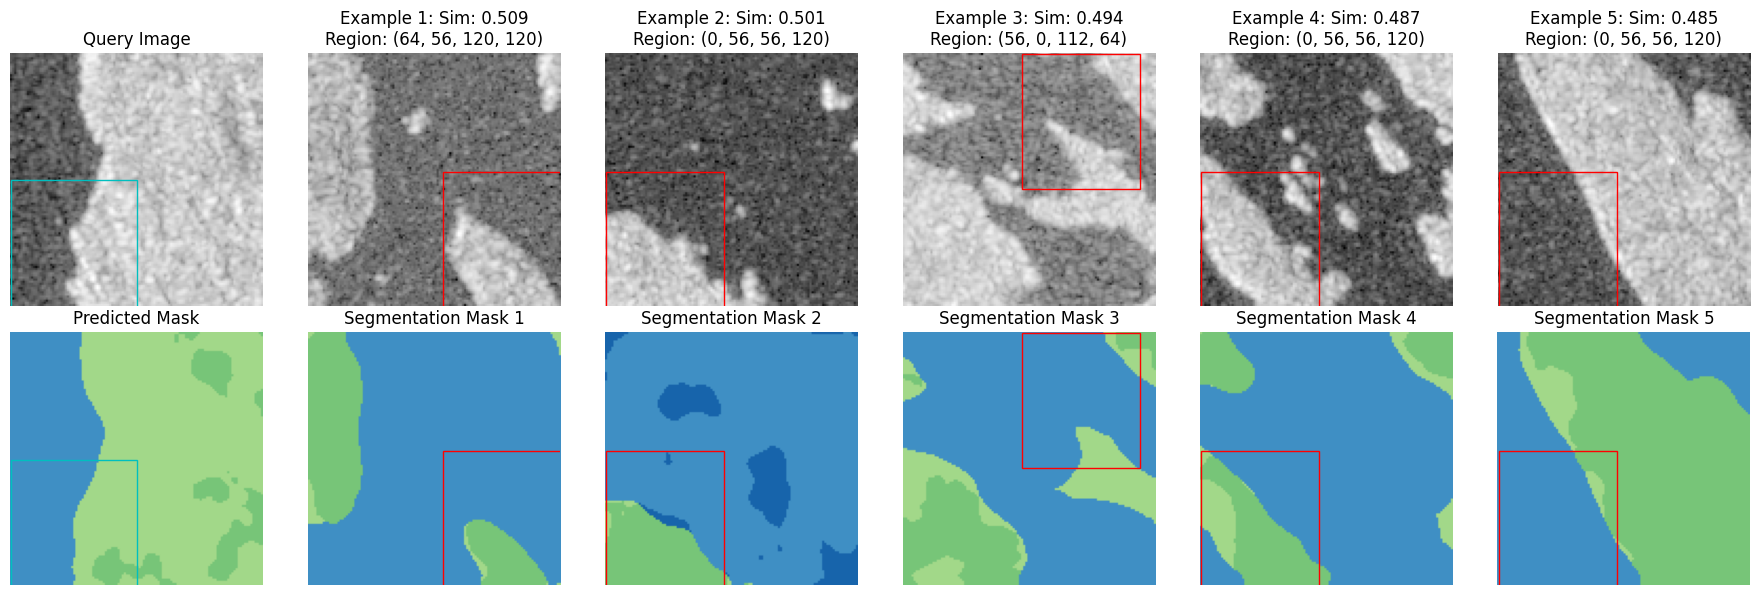

   Results for layer: encoder.layer4
   Top N Results: [(0.4314984679222107, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_68_6', (56, 56, 112, 120)), (0.4163774251937866, 'S1A_IW_GRDH_1SDV_20180521T044858_34WFS_6_88', (56, 56, 112, 120)), (0.4136797785758972, 'S1A_IW_GRDH_1SDV_20180521T044858_34WFS_6_88', (64, 56, 120, 120)), (0.40584152936935425, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_81_40', (0, 56, 56, 120)), (0.4029846489429474, 'S1B_IW_GRDH_1SDV_20180524T042416_35VNK_56_89', (64, 56, 120, 120)), (0.40080317854881287, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_67_10', (0, 56, 56, 120)), (0.3960687220096588, 'S1B_IW_GRDH_1SDV_20170709T043159_35VNL_83_5', (64, 56, 120, 120)), (0.3904690444469452, 'S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_81_40', (56, 56, 112, 120)), (0.3895813822746277, 'S1B_IW_GRDH_1SDV_20180524T042416_35VNK_56_89', (56, 56, 112, 120)), (0.3894922435283661, 'S1B_IW_GRDH_1SDV_20180524T153951_35VNH_57_12', (64, 56, 120, 120)), (0.3885171413421631, 'S1B_IW_GRDH_1SDV_20171101T15

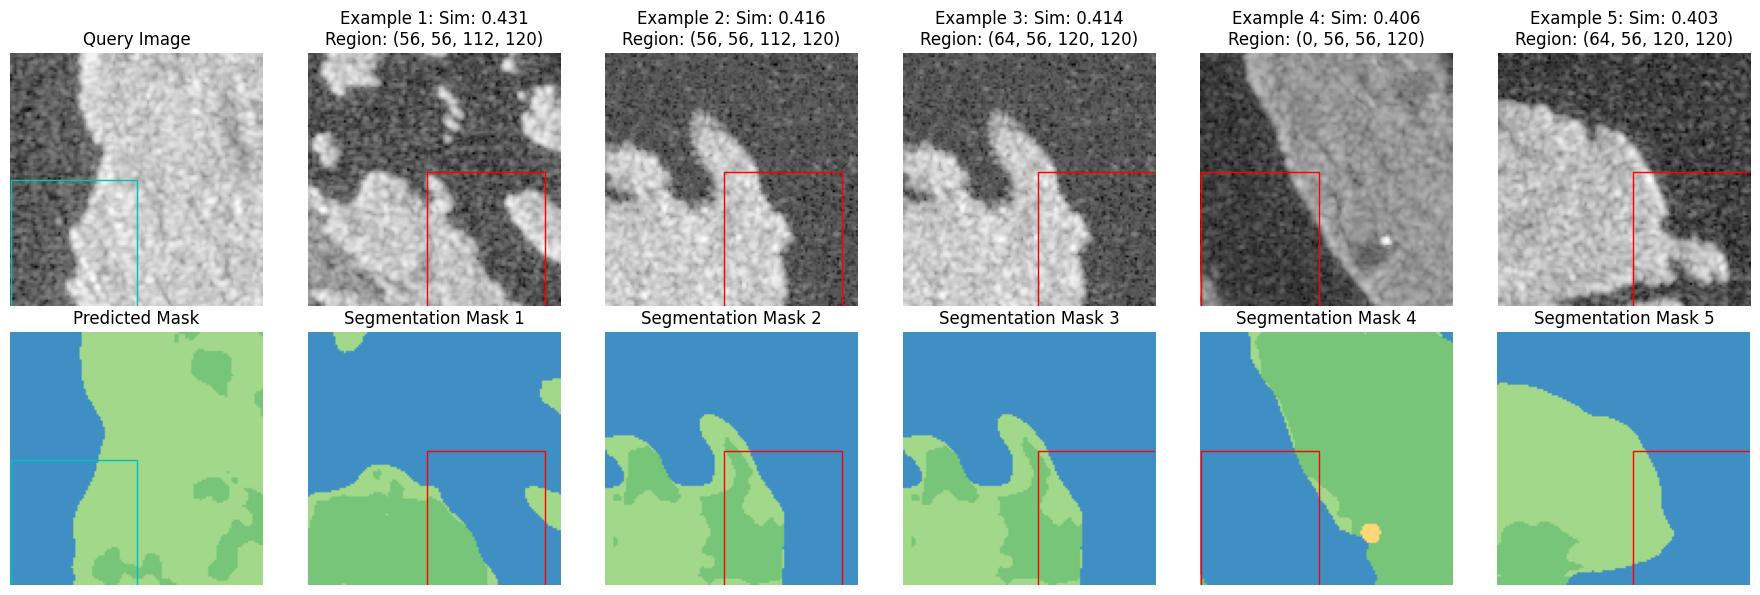

   Results for layer: decoder.aspp
   Top N Results: [(0.766339898109436, 'S1A_IW_GRDH_1SDV_20180516T044113_35VNJ_47_11', (56, 0, 112, 64)), (0.7662122249603271, 'S1B_IW_GRDH_1SDV_20170924T044105_35VNH_5_18', (56, 56, 112, 120)), (0.7658993005752563, 'S1A_IW_GRDH_1SDV_20180516T044113_35VNJ_47_11', (64, 0, 120, 64)), (0.7622523307800293, 'S1A_IW_GRDH_1SDV_20180523T043256_35VPJ_15_2', (64, 0, 120, 64)), (0.7611483335494995, 'S1A_IW_GRDH_1SDV_20170925T043256_35VPK_10_82', (0, 56, 56, 120)), (0.7584844827651978, 'S1A_IW_GRDH_1SDV_20180525T153234_35VNK_74_82', (56, 56, 112, 120)), (0.7578759789466858, 'S1A_IW_GRDH_1SDV_20170906T155749_34WFS_87_73', (0, 56, 56, 120)), (0.7574167847633362, 'S1A_IW_GRDH_1SDV_20180525T153259_35VNL_54_79', (64, 56, 120, 120)), (0.7568619251251221, 'S1A_IW_GRDH_1SDV_20180523T043256_35VPJ_9_25', (64, 56, 120, 120)), (0.7560503482818604, 'S1A_IW_GRDH_1SDV_20180513T153233_35VNJ_85_39', (64, 56, 120, 120)), (0.7554638385772705, 'S1B_IW_GRDH_1SDV_20170924T044105_35VNH

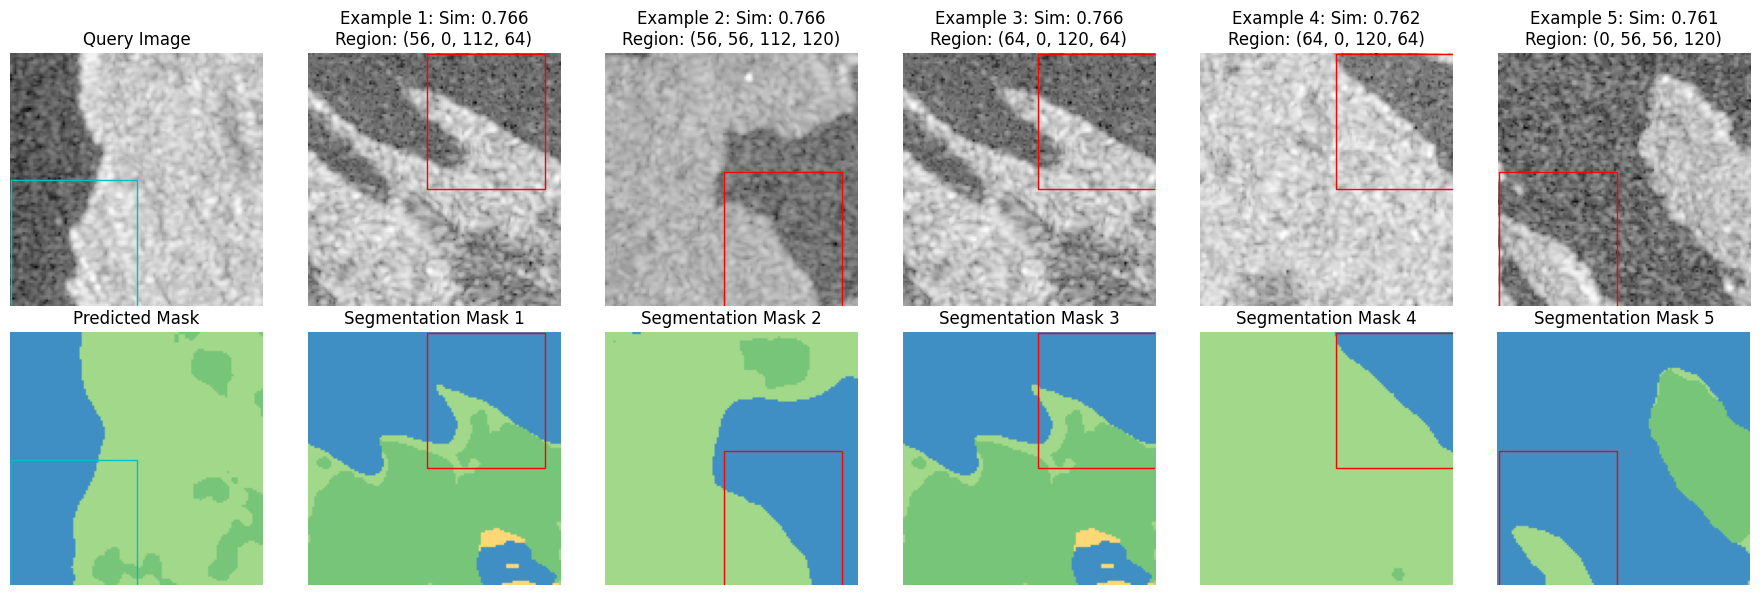

   Results for layer: decoder.block2
   Top N Results: [(0.9187417030334473, 'S1B_IW_GRDH_1SDV_20170924T044040_35VNH_6_9', (0, 60, 60, 120)), (0.9162172675132751, 'S1A_IW_GRDH_1SDV_20170925T043321_35VNH_76_10', (0, 60, 60, 120)), (0.9157063961029053, 'S1A_IW_GRDH_1SDV_20170903T153323_35WPN_1_65', (0, 0, 60, 60)), (0.9153133630752563, 'S1A_IW_GRDH_1SDV_20180513T153233_35VNJ_83_30', (60, 0, 120, 60)), (0.9143774509429932, 'S1A_IW_GRDH_1SDV_20180523T043321_35VPJ_14_78', (0, 60, 60, 120)), (0.9036188721656799, 'S1A_IW_GRDH_1SDV_20180415T160451_35VLG_6_15', (0, 60, 60, 120)), (0.9021334648132324, 'S1B_IW_GRDH_1SDV_20170924T044040_35VNH_6_10', (0, 60, 60, 120)), (0.9005298614501953, 'S1A_IW_GRDH_1SDV_20180516T044138_35VNJ_10_90', (0, 0, 60, 60)), (0.9003140926361084, 'S1B_IW_GRDH_1SDV_20180524T154016_35VNK_33_5', (60, 0, 120, 60)), (0.8995286822319031, 'S1B_IW_GRDH_1SDV_20170924T044040_35VNH_6_10', (0, 0, 60, 60)), (0.8970837593078613, 'S1B_IW_GRDH_1SDV_20171101T042417_35VNK_79_53', (60, 0, 

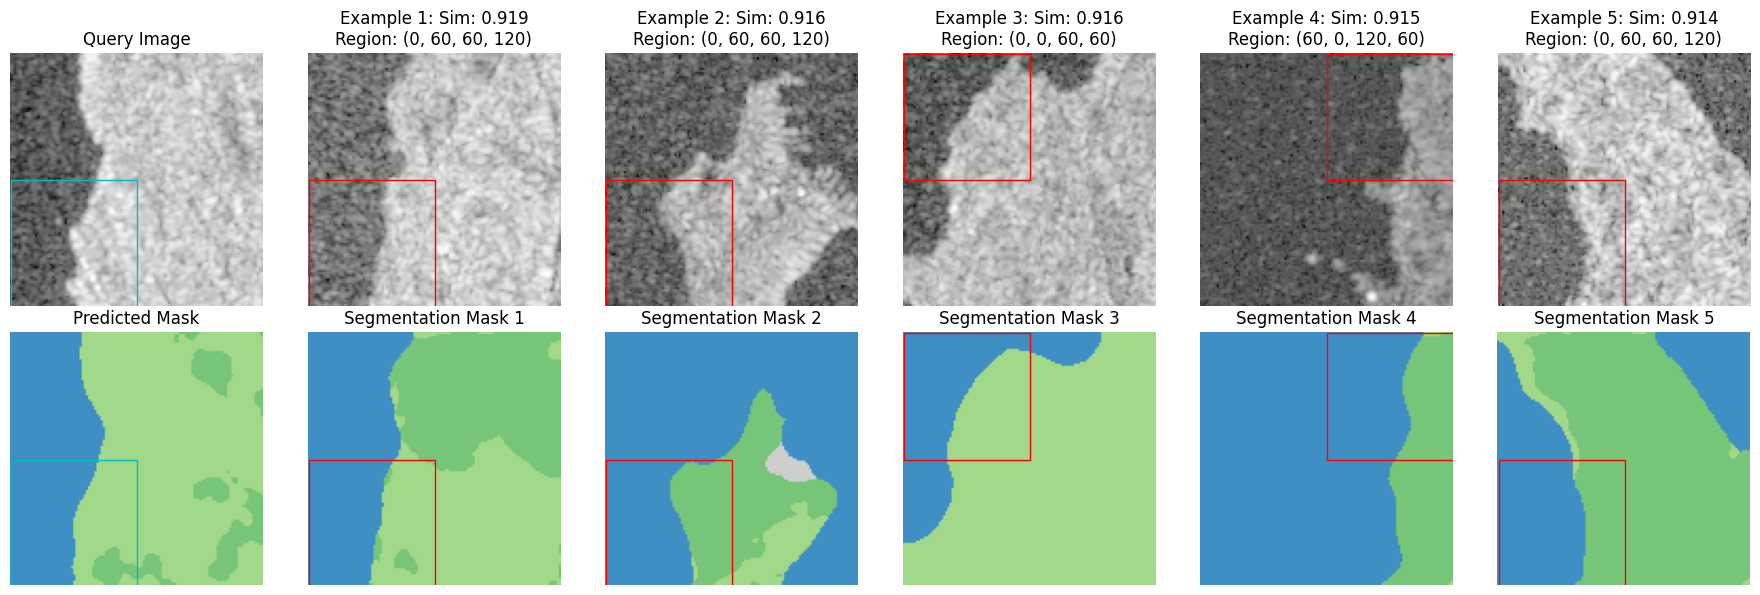

In [8]:
layer_names = DEEPLABV3P_ACTIVATION_LAYERS
_, scale_factors_deeplabv3p = get_layer_config("deeplabv3p")
test_top_n = find_n_similar_images(
                            #random_test_imgs[0],
                            test_img,
                            layer_names,
                            subsample_image_keys[:],
                            examples_lmdb_path,
                            dataset_lmdb_path,
                            model,
                            img_hw=IMG_SIZE,
                            #region_coords=random_regions[0],
                            region_coords = (0,60,60,120),
                            n=5,
                            plotting = True,
                            scale_factors=scale_factors_deeplabv3p,
                            arch_name="deeplabv3p",
                            dtype=torch.float16
                        )



